# Currency Call Option

- This program is building a Currency Call Option calculator to mimick the derivatives on the GBP/USD=X Exchange rate.

### Libraries and pip installs

In [3]:
# First, install all needed libraries in the notebook
!pip install numpy --quiet
!pip install matplotlib --quiet
!pip install pandas --quiet
!pip install scipy --quiet
!pip install yfinance --quiet
!pip install statsmodels --quiet

In [4]:
# Importing all additionally needed libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
from scipy.stats import norm
import yfinance as yf
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import adfuller

- Numpy is used mainly for simpler math calculations like exp() or sqrt()
- matplotlib.pyplot as plt is used for plotting the processed data
- pandas is used for tabular data and spreadsheet visualisation
- scipy adds statistical tools which are used to evaluate the data
- yfinance is used to download historical asset data, which is already machine-usable when processing
- statsmodel is used to import two tests, the Ljung-Box for autocorrelation and the Augmented Dickey-Fuller Test for Stationarity, this compactly adds to the prove of GBM

### Importing Data

- Download the historical exchange rate data for GBPUSD=X from yahoo finance over the last 10 years, from 28.05.2015 until 31.05.2025. Since we will be looking only at adjusted Close prices, we will only download this specific section. This will also lower computation power usage, making the program run faster and more efficient.

In [8]:
# Importing 10 year historical GBP/USD data.
GBP_USD = pd.DataFrame(yf.download("GBPUSD=X", start="2015-05-28", end="2025-05-31", auto_adjust=False)[["Adj Close"]]).dropna()
print(GBP_USD)

[*********************100%***********************]  1 of 1 completed

Price      Adj Close
Ticker      GBPUSD=X
Date                
2015-05-28  1.535014
2015-05-29  1.531910
2015-06-01  1.528888
2015-06-02  1.519988
2015-06-03  1.533978
...              ...
2025-05-26  1.353583
2025-05-27  1.356521
2025-05-28  1.351333
2025-05-29  1.343147
2025-05-30  1.349899

[2606 rows x 1 columns]


- For easier datastorage we will now download the exchange rates to then turn them into log-normalized returns. Obviously we are using the Adj Close column for our analysis. During that NaN cells will be deleted as well
Since we do not need the Adj Close column any more, we get rid of it.

In [ ]:
# Importing 10 year historical GBP/USD data and log-normalizing it.
GBP_USD_ln = pd.DataFrame(yf.download("GBPUSD=X", start="2015-05-28", end="2025-05-31", auto_adjust=False)[["Adj Close"]]).dropna()
GBP_USD_ln['log_return'] = np.log(GBP_USD_ln['Adj Close'] / GBP_USD_ln['Adj Close'].shift(1))
GBP_USD_ln.drop(columns=['Adj Close'], inplace=True)
GBP_USD_ln.drop(index=['2015-05-28'], inplace=True)
print(GBP_USD_ln)

[*********************100%***********************]  1 of 1 completed

Price      log_return
Ticker               
Date                 
2015-05-29  -0.002024
2015-06-01  -0.001974
2015-06-02  -0.005838
2015-06-03   0.009162
2015-06-04  -0.000859
...               ...
2025-05-26   0.008652
2025-05-27   0.002168
2025-05-28  -0.003832
2025-05-29  -0.006076
2025-05-30   0.005014

[2605 rows x 1 columns]


- These steps here are just for easier processing of the underlying data in the code. We will be splitting up the data in the time horizons, and for that reason need two underlying sets, because the drop.na() changes the original set as well in the data processing here.

### Proving GBM for each time horizon

### 1-YEAR

- Now we are splitting up the dataset into our time horizóns, making it much easier to work with, when using 4 different time frames. Here, for the 1 year historical prices.

In [ ]:
# Isolating the range
rt_1y = GBP_USD.loc["2024-05-30":"2025-06-01"].dropna()

Price      Adj Close
Ticker      GBPUSD=X
Date                
2024-05-30  1.269799
2024-05-31  1.273042
2024-06-03  1.274372
2024-06-04  1.281017
2024-06-05  1.277302
...              ...
2025-05-26  1.353583
2025-05-27  1.356521
2025-05-28  1.351333
2025-05-29  1.343147
2025-05-30  1.349899

[259 rows x 1 columns]


- Now we are plotting the historical adjusted closing prices of the 1 year time frame

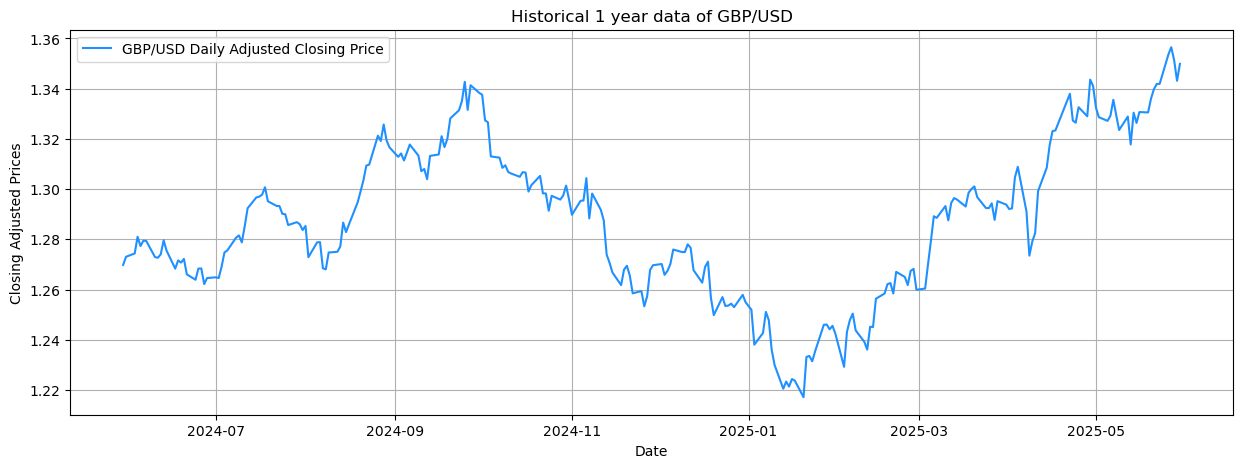

In [19]:
# Plotting the data
plt.figure(figsize=(15, 5))
plt.grid(True)
plt.title("Historical 1 year data of GBP/USD")
plt.xlabel("Date")
plt.ylabel("Closing Adjusted Prices")
plt.plot(rt_1y["Adj Close"], label="GBP/USD Daily Adjusted Closing Price", color = "dodgerblue")
plt.legend()
plt.show()

- Now we are splitting up the dataset into our time horizóns, making it much easier to work with, when using 4 different time frames. Here for the 1 year historical log-normalized returns.

In [ ]:
# Isolating the range log-n
ln_rt_1y = GBP_USD_ln.loc["2024-05-30":"2025-06-01"].dropna()
print(ln_rt_1y)

Price      log_return
Ticker               
Date                 
2024-05-30  -0.004742
2024-05-31   0.002550
2024-06-03   0.001044
2024-06-04   0.005200
2024-06-05  -0.002904
...               ...
2025-05-26   0.008652
2025-05-27   0.002168
2025-05-28  -0.003832
2025-05-29  -0.006076
2025-05-30   0.005014

[259 rows x 1 columns]


- Now we are plotting the historical log-normalized returns of the 1 year time frame

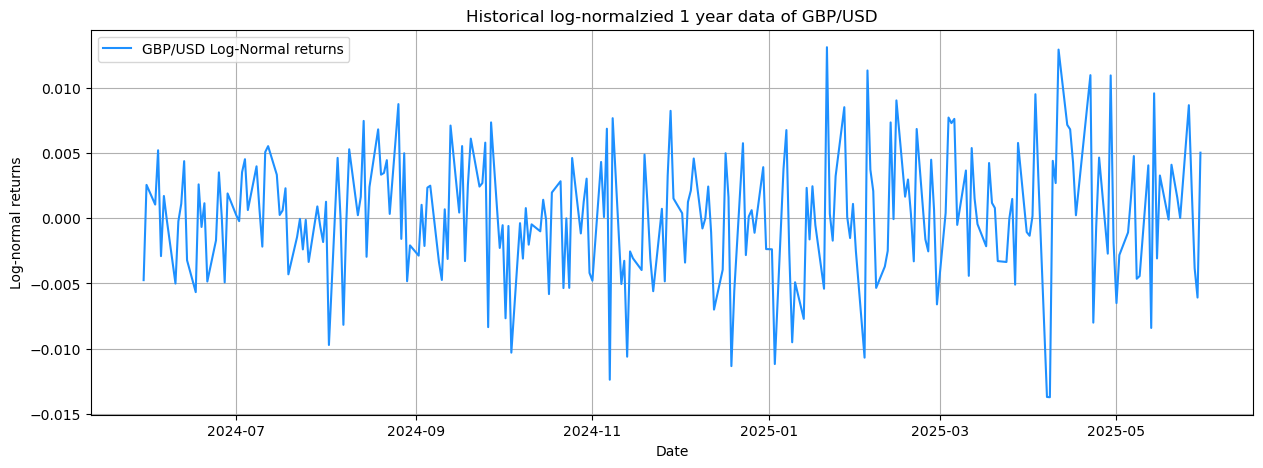

In [24]:
# Plotting the data
plt.figure(figsize=(15, 5))
plt.grid(True)
plt.title("Historical log-normalzied 1 year data of GBP/USD")
plt.xlabel("Date")
plt.ylabel("Log-normal returns")
plt.plot(ln_rt_1y["log_return"], label="GBP/USD Log-Normal returns", color = "dodgerblue")
plt.legend()
plt.show()

In [ ]:
# Calculating daily and annual mean
daily_mean = np.mean(ln_rt_1y)
annual_mean = daily_mean * 250

# Calculating daily and annual standard deviation
daily_std = np.std(ln_rt_1y)
annual_std = daily_std * np.sqrt(250)

C:\Users\osama\anaconda3\Lib\site-packages\numpy\core\fromnumeric.py:3643: FutureWarning: The behavior of DataFrame.std with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return std(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)


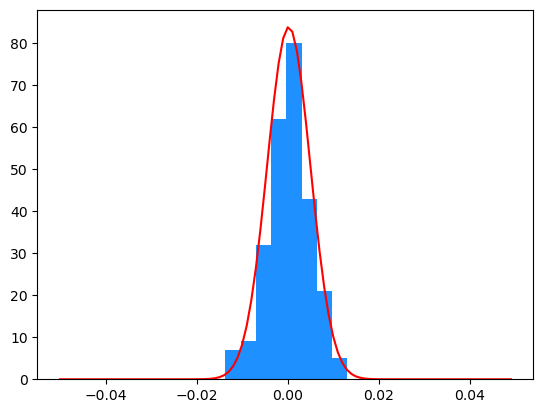

In [ ]:
x = np.arange(-0.05,0.05,0.001)
plt.hist(ln_rt_1y, bins = 8, color = "dodgerblue")
plt.plot(x, norm.pdf(x, daily_mean, daily_std), color = "red")

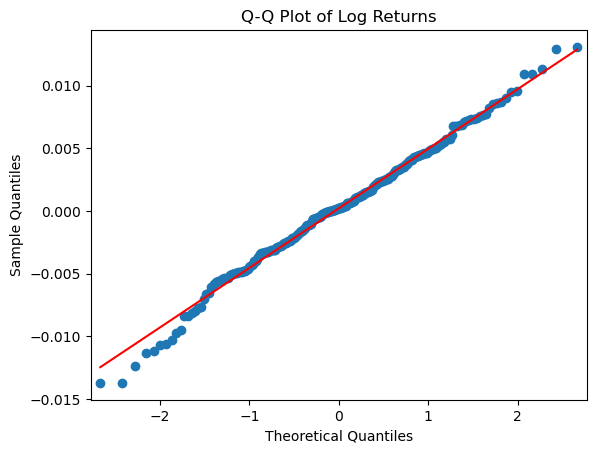

In [ ]:
lr1 = ln_rt_1y['log_return'].dropna()
sm.qqplot(lr1, line="s")
plt.title("Q-Q Plot of Log Returns")
plt.show()

- Now we are going to test the auto correlation of the underlying log returns.
- If the p-value is below 0.05, we can reject the autocorrelation -> No autocorrelation when $p>0.05$, needed for GBM

In [33]:
acorr_ljungbox(lr1, lags=[10], return_df=True)

,lb_stat,lb_pvalue
10,10.317389,0.413103


<Axes: title={'center': '30-Day Rolling Volatility'}, xlabel='Date'>

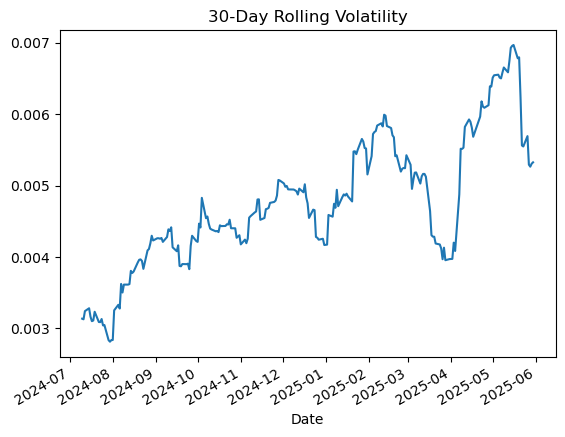

In [ ]:
lr1['rolling_vol'] = lr1.rolling(window=30).std()
lr1['rolling_vol'].plot(title="30-Day Rolling Volatility")

- Now we are going to test the stationarity of the log returns with the augmented Dickey-Fulley Test. Here, if the p-value is below 0.05, we know that the log-returns are stationary.

In [ ]:
adf_stat = adfuller(ln_rt_1y)
print("ADF p-value:", adf_stat[1])

ADF p-value: 1.7288900202366025e-29


### 2-YEAR

In [ ]:
# Isolating the range
rt_2y = GBP_USD.loc["2023-05-30":"2025-06-01"].dropna()
print(rt_2y)

Price      Adj Close
Ticker      GBPUSD=X
Date                
2023-05-30  1.234934
2023-05-31  1.241188
2023-06-01  1.244694
2023-06-02  1.252599
2023-06-05  1.243024
...              ...
2025-05-26  1.353583
2025-05-27  1.356521
2025-05-28  1.351333
2025-05-29  1.343147
2025-05-30  1.349899

[521 rows x 1 columns]


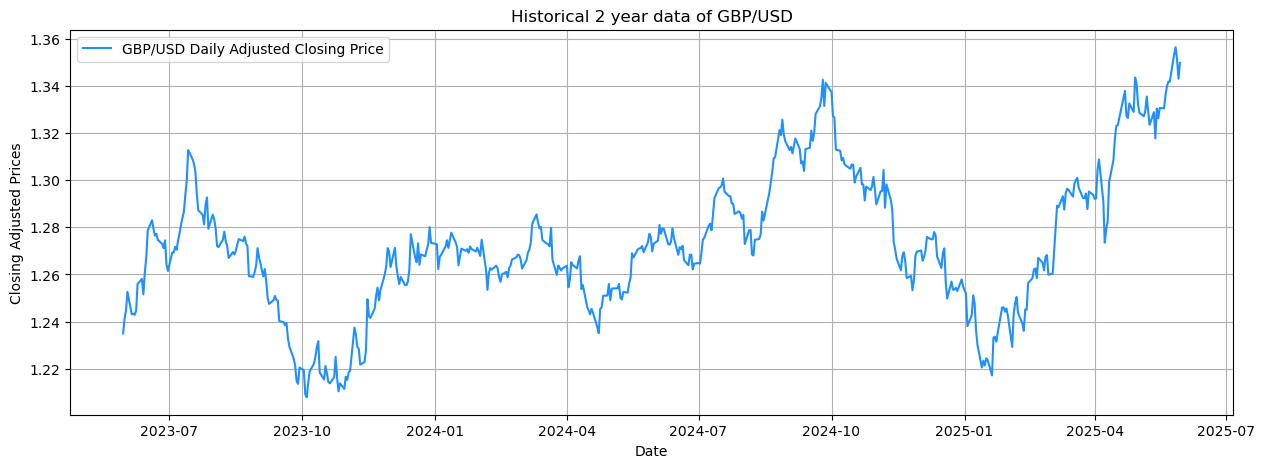

In [42]:
# Plotting the data
plt.figure(figsize=(15, 5))
plt.grid(True)
plt.title("Historical 2 year data of GBP/USD")
plt.xlabel("Date")
plt.ylabel("Closing Adjusted Prices")
plt.plot(rt_2y["Adj Close"], label="GBP/USD Daily Adjusted Closing Price", color = "dodgerblue")
plt.legend()
plt.show()

In [ ]:
# Isolating the range log-n
ln_rt_2y = GBP_USD_ln.loc["2023-05-30":"2025-06-01"].dropna()
print(ln_rt_2y)

Price      log_return
Ticker               
Date                 
2023-05-30   0.000198
2023-05-31   0.005051
2023-06-01   0.002821
2023-06-02   0.006331
2023-06-05  -0.007674
...               ...
2025-05-26   0.008652
2025-05-27   0.002168
2025-05-28  -0.003832
2025-05-29  -0.006076
2025-05-30   0.005014

[521 rows x 1 columns]


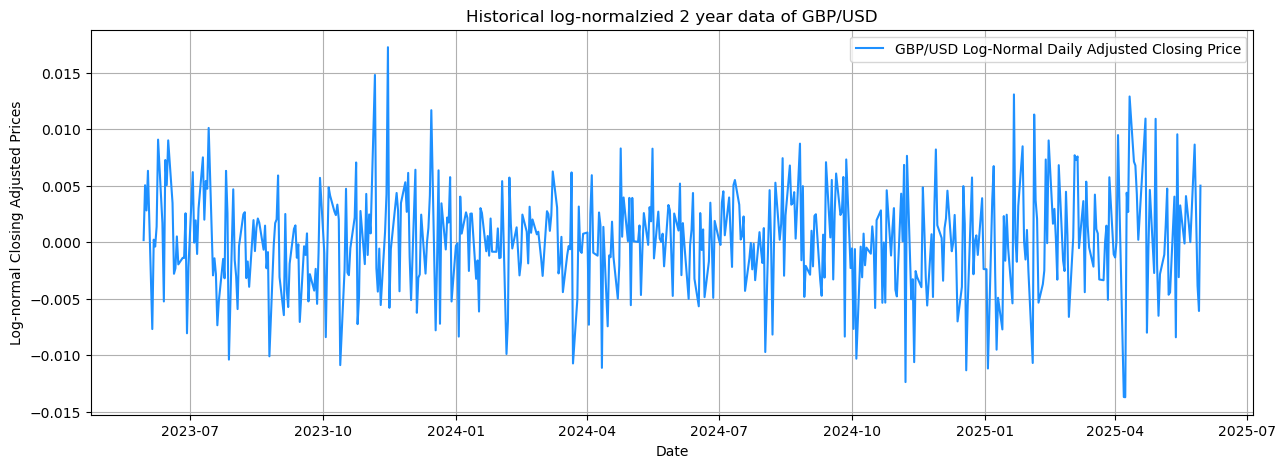

In [45]:
# Plotting the data
plt.figure(figsize=(15, 5))
plt.grid(True)
plt.title("Historical log-normalzied 2 year data of GBP/USD")
plt.xlabel("Date")
plt.ylabel("Log-normal Closing Adjusted Prices")
plt.plot(ln_rt_2y["log_return"], label="GBP/USD Log-Normal Daily Adjusted Closing Price", color = "dodgerblue")
plt.legend()
plt.show()

Sources of the subsequent code: [[3]](#3) , [[4]](#4)

In [ ]:
daily_mean = np.mean(ln_rt_2y)
annual_mean = daily_mean * 250

# Calculating daily and annual standard deviation
daily_std = np.std(ln_rt_2y)
annual_std = daily_std * np.sqrt(250)

C:\Users\osama\anaconda3\Lib\site-packages\numpy\core\fromnumeric.py:3643: FutureWarning: The behavior of DataFrame.std with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return std(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)


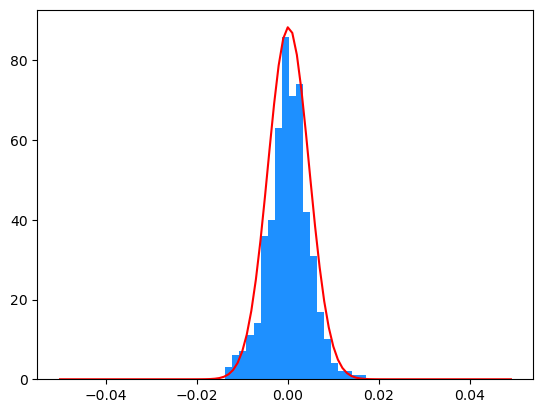

In [ ]:
x = np.arange(-0.05,0.05,0.001)
plt.hist(ln_rt_2y, bins = 20, color = "dodgerblue")
plt.plot(x, norm.pdf(x, daily_mean, daily_std), color = "red")

Source of the subsequent code: [[7]](#7)

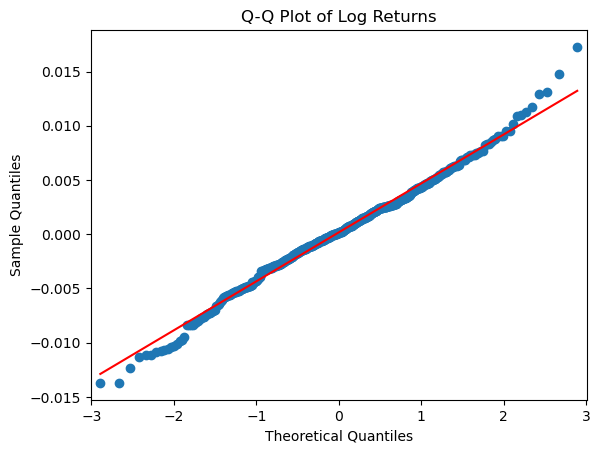

In [ ]:
lr2 = ln_rt_2y['log_return'].dropna()
sm.qqplot(lr2, line="s")
plt.title("Q-Q Plot of Log Returns")
plt.show()

In [53]:
acorr_ljungbox(lr2, lags=[10], return_df=True)

,lb_stat,lb_pvalue
10,4.083215,0.943515


<Axes: title={'center': '30-Day Rolling Volatility'}, xlabel='Date'>

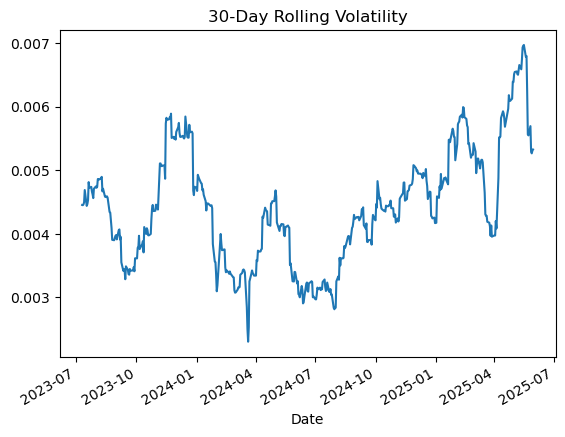

In [ ]:
ln_rt_2y['rolling_vol'] = lr2.rolling(window=30).std()
ln_rt_2y['rolling_vol'].plot(title="30-Day Rolling Volatility")

In [ ]:
adf_stat = adfuller(lr2)
print("ADF p-value:", adf_stat[1])

ADF p-value: 0.0


### 5-YEAR

In [ ]:
# Isolating the range
rt_5y = GBP_USD.loc["2020-05-30":"2025-06-01"].dropna()
print(rt_5y)

Price      Adj Close
Ticker      GBPUSD=X
Date                
2020-06-01  1.234800
2020-06-02  1.248704
2020-06-03  1.258147
2020-06-04  1.257514
2020-06-05  1.260907
...              ...
2025-05-26  1.353583
2025-05-27  1.356521
2025-05-28  1.351333
2025-05-29  1.343147
2025-05-30  1.349899

[1302 rows x 1 columns]


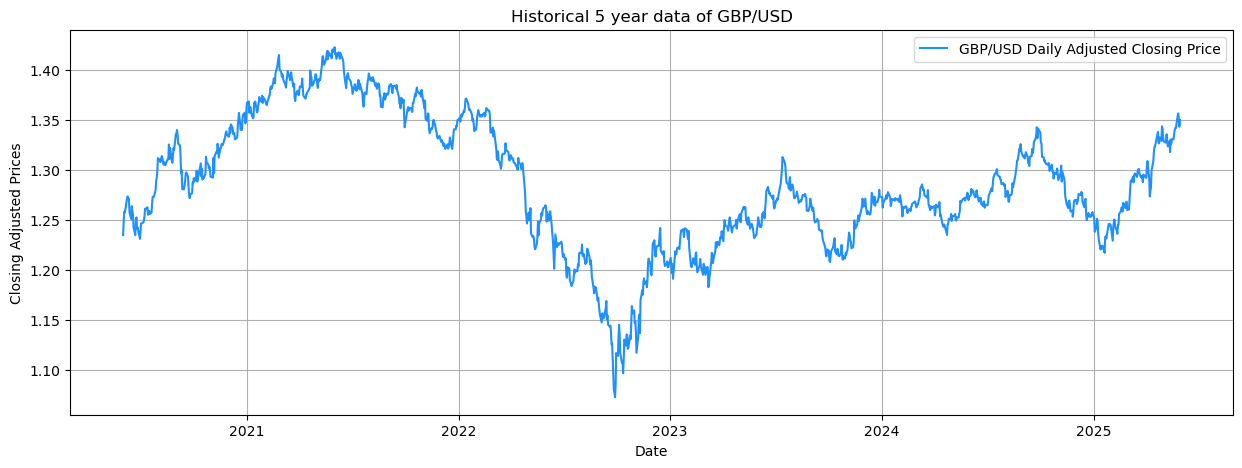

In [61]:
# Plotting the data
plt.figure(figsize=(15, 5))
plt.grid(True)
plt.title("Historical 5 year data of GBP/USD")
plt.xlabel("Date")
plt.ylabel("Closing Adjusted Prices")
plt.plot(rt_5y["Adj Close"], label="GBP/USD Daily Adjusted Closing Price", color = "dodgerblue")
plt.legend()
plt.show()

In [ ]:
# Isolating the range log-n
ln_rt_5y = GBP_USD_ln.loc["2020-05-30":"2025-06-01"].dropna()
print(ln_rt_5y)

Price      log_return
Ticker               
Date                 
2020-06-01   0.002149
2020-06-02   0.011198
2020-06-03   0.007533
2020-06-04  -0.000503
2020-06-05   0.002695
...               ...
2025-05-26   0.008652
2025-05-27   0.002168
2025-05-28  -0.003832
2025-05-29  -0.006076
2025-05-30   0.005014

[1302 rows x 1 columns]


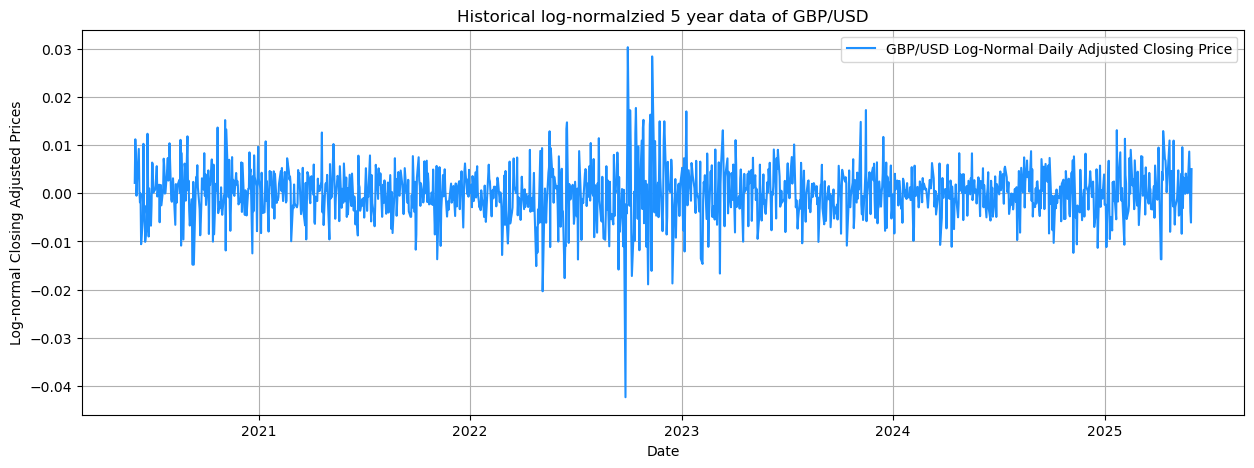

In [64]:
# Plotting the data
plt.figure(figsize=(15, 5))
plt.grid(True)
plt.title("Historical log-normalzied 5 year data of GBP/USD")
plt.xlabel("Date")
plt.ylabel("Log-normal Closing Adjusted Prices")
plt.plot(ln_rt_5y["log_return"], label="GBP/USD Log-Normal Daily Adjusted Closing Price", color = "dodgerblue")
plt.legend()
plt.show()

In [ ]:
# Calculating daily and annual mean
daily_mean = np.mean(ln_rt_5y)
annual_mean = daily_mean * 250

# Calculating daily and annual standard deviation
daily_std = np.std(ln_rt_5y)
annual_std = daily_std * np.sqrt(250)

C:\Users\osama\anaconda3\Lib\site-packages\numpy\core\fromnumeric.py:3643: FutureWarning: The behavior of DataFrame.std with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return std(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)


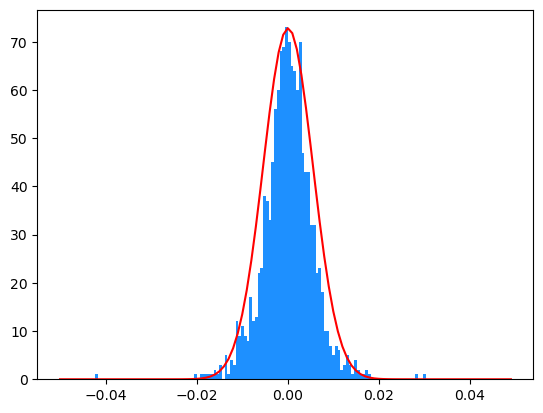

In [ ]:
x = np.arange(-0.05,0.05,0.001)
plt.hist(ln_rt_5y, bins = 120, color = "dodgerblue")
plt.plot(x, norm.pdf(x, daily_mean, daily_std), color = "red")

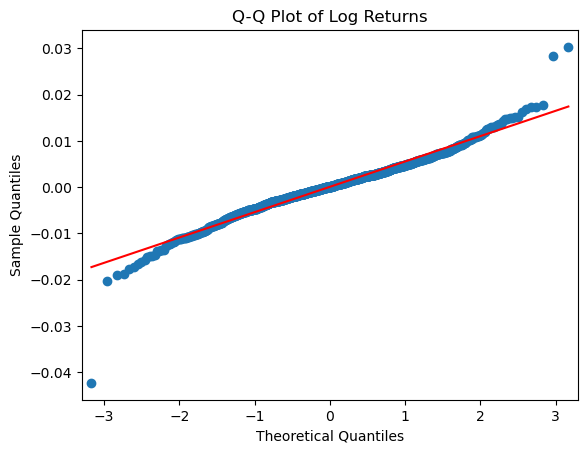

In [ ]:
lr5 = ln_rt_5y['log_return'].dropna()
sm.qqplot(lr5, line="s")
plt.title("Q-Q Plot of Log Returns")
plt.show()

In [72]:
acorr_ljungbox(lr5, lags=[10], return_df=True)

,lb_stat,lb_pvalue
10,11.098595,0.349888


<Axes: title={'center': '30-Day Rolling Volatility'}, xlabel='Date'>

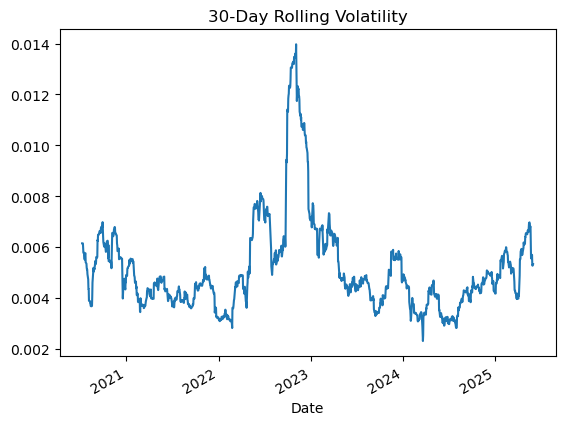

In [ ]:
ln_rt_5y['rolling_vol'] = lr5.rolling(window=30).std()
ln_rt_5y['rolling_vol'].plot(title="30-Day Rolling Volatility")

In [ ]:
adf_stat = adfuller(lr5)
print("ADF p-value:", adf_stat[1])

ADF p-value: 0.0


### 10-YEAR

In [ ]:
# Isolating the range
rt_10y = GBP_USD.loc["2015-05-30":"2025-06-01"].dropna()
print(rt_10y)

Price      Adj Close
Ticker      GBPUSD=X
Date                
2015-06-01  1.528888
2015-06-02  1.519988
2015-06-03  1.533978
2015-06-04  1.532661
2015-06-05  1.536500
...              ...
2025-05-26  1.353583
2025-05-27  1.356521
2025-05-28  1.351333
2025-05-29  1.343147
2025-05-30  1.349899

[2604 rows x 1 columns]


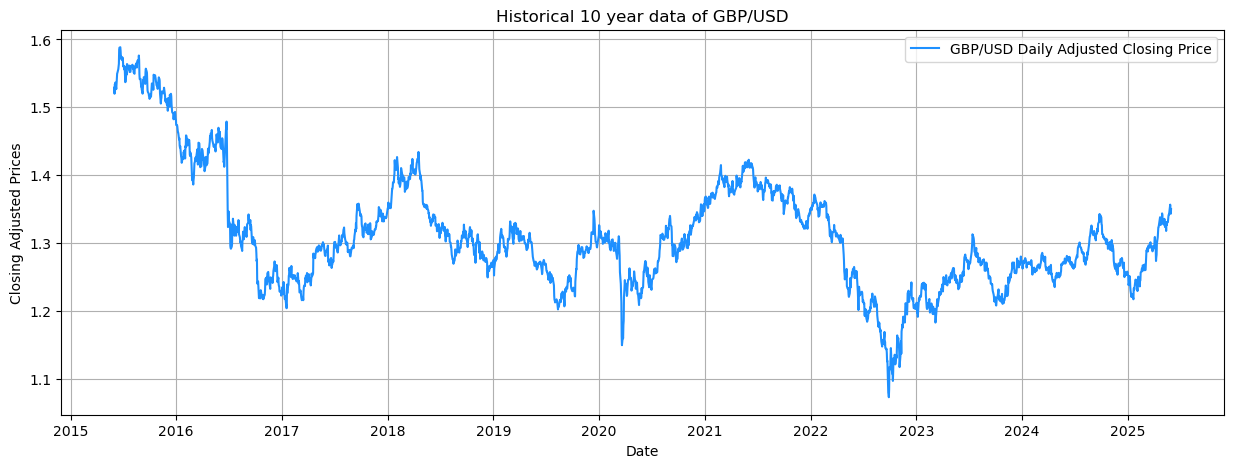

In [80]:
# Plotting the data
plt.figure(figsize=(15, 5))
plt.grid(True)
plt.title("Historical 10 year data of GBP/USD")
plt.xlabel("Date")
plt.ylabel("Closing Adjusted Prices")
plt.plot(rt_10y["Adj Close"], label="GBP/USD Daily Adjusted Closing Price", color = "dodgerblue")
plt.legend()
plt.show()

In [ ]:
# Isolating the range log-n
ln_rt_10y = GBP_USD_ln.loc["2015-05-30":"2025-06-01"].dropna()
print(ln_rt_10y)

Price      log_return
Ticker               
Date                 
2015-06-01  -0.001974
2015-06-02  -0.005838
2015-06-03   0.009162
2015-06-04  -0.000859
2015-06-05   0.002501
...               ...
2025-05-26   0.008652
2025-05-27   0.002168
2025-05-28  -0.003832
2025-05-29  -0.006076
2025-05-30   0.005014

[2604 rows x 1 columns]


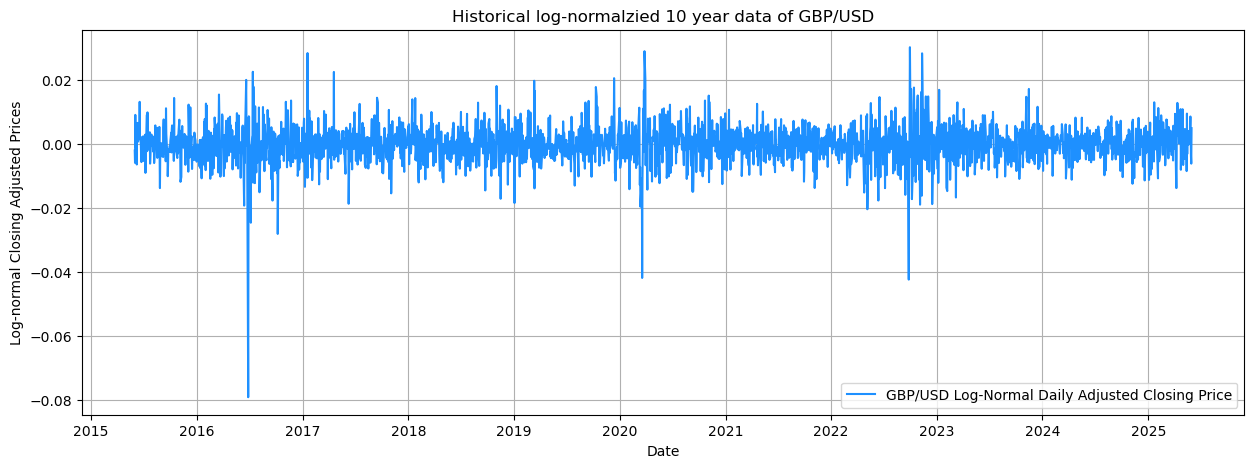

In [83]:
# Plotting the data
plt.figure(figsize=(15, 5))
plt.grid(True)
plt.title("Historical log-normalzied 10 year data of GBP/USD")
plt.xlabel("Date")
plt.ylabel("Log-normal Closing Adjusted Prices")
plt.plot(ln_rt_10y["log_return"], label="GBP/USD Log-Normal Daily Adjusted Closing Price", color = "dodgerblue")
plt.legend()
plt.show()

In [ ]:
# Calculating daily and annual mean
daily_mean = np.mean(ln_rt_10y)
annual_mean = daily_mean * 250

# Calculating daily and annual standard deviation
daily_std = np.std(ln_rt_10y)
annual_std = daily_std * np.sqrt(250)

C:\Users\osama\anaconda3\Lib\site-packages\numpy\core\fromnumeric.py:3643: FutureWarning: The behavior of DataFrame.std with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return std(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)


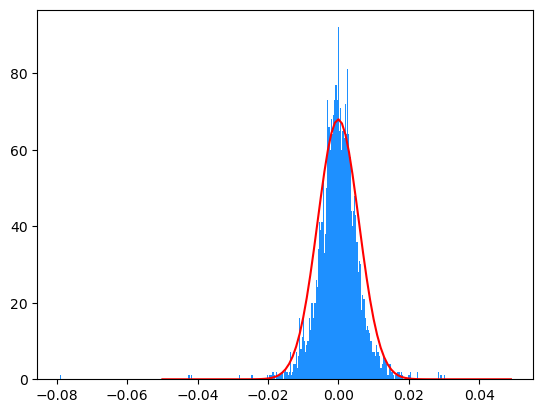

In [ ]:
x = np.arange(-0.05,0.05,0.001)
plt.hist(ln_rt_10y, bins = 330, color = "dodgerblue")
plt.plot(x, norm.pdf(x, daily_mean, daily_std), color = "red")

Source of the subsequent code: [[7]](#7)

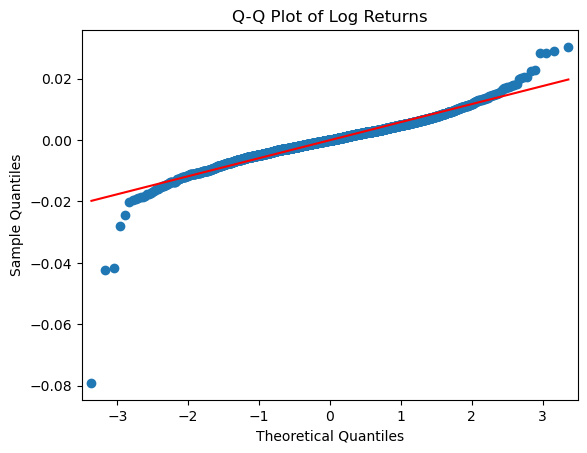

In [ ]:
lr10 = ln_rt_10y['log_return'].dropna()
sm.qqplot(lr10, line="s")
plt.title("Q-Q Plot of Log Returns")
plt.show()

In [91]:
acorr_ljungbox(lr10, lags=[10], return_df=True)

,lb_stat,lb_pvalue
10,11.724577,0.303912


<Axes: title={'center': '30-Day Rolling Volatility'}, xlabel='Date'>

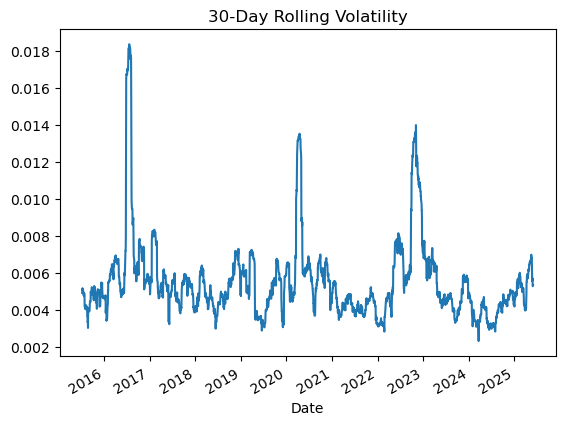

In [ ]:
ln_rt_10y['rolling_vol'] = lr10.rolling(window=30).std()
ln_rt_10y['rolling_vol'].plot(title="30-Day Rolling Volatility")

In [ ]:
adf_stat = adfuller(lr10)
print("ADF p-value:", adf_stat[1])

ADF p-value: 0.0


### Results GBM Prove
- From our summary we can conclude, that the different time spans have matched all criteria to be meeting a GBM. For that reason we can now start our BSM models on them.

In [97]:
results = {
    "1Y": {"Normality": "Yes", "Autocorr": 0.413103, "ADF": 1.7288900202365902e-29, "Homoskedasticity": "Yes"},
    "2Y": {"Normality": "Yes", "Autocorr": 0.943515, "ADF": 0.00, "Homoskedasticity": "Yes"},
    "5Y": {"Normality": "Yes", "Autocorr": 0.349888, "ADF": 0.00, "Homoskedasticity": "Yes"},
    "10Y": {"Normality": "Yes", "Autocorr": 0.303912, "ADF": 0.00, "Homoskedasticity": "Yes"}
}


In [ ]:
summary_table = pd.DataFrame(results).T
summary_table.columns = ["Normal-looking", "Ljung-Box (p)", "ADF (p)", "Homoskedastic?"]
summary_table.index.name = "Time Span"
summary_table["GBM still applicable?"] = summary_table.apply(
    lambda row: "Yes" if row["Normal-looking"] == "Yes" and row["Ljung-Box (p)"] > 0.05 and row["ADF (p)"] < 0.05 and row["Homoskedastic?"] == "Yes" else "No",
    axis=1
)

print(summary_table)

          Normal-looking Ljung-Box (p) ADF (p) Homoskedastic?  \
Time Span                                                       
1Y                   Yes      0.413103     0.0            Yes   
2Y                   Yes      0.943515     0.0            Yes   
5Y                   Yes      0.349888     0.0            Yes   
10Y                  Yes      0.303912     0.0            Yes   

          GBM still applicable?  
Time Span                        
1Y                          Yes  
2Y                          Yes  
5Y                          Yes  
10Y                         Yes  


## Modeling Black-Scholes-Merton-Model

- BSM-Modeling of Call Option prices on different time horizons

### Defining Call Option BSM Function

In [ ]:
# Black-Scholes-Model for call option pricing 2 Year
def call_option_bsm (S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    call = (S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2))
    return call

# Risk free rate - Using Bank of England Bank rate (average over the last 10 years)
r = 0.0156

### 1-YEAR

In [ ]:
rt_1y['Returns'] = rt_1y['Adj Close'].pct_change()
rt_1y = rt_1y.dropna()
print(rt_1y)

# Daily historical volatility (annualized)
rt_1y["volatility"] = rt_1y["Returns"].rolling(window = 30).std() * np.sqrt(252)
rt_1y = rt_1y.dropna().copy()

Price      Adj Close   Returns
Ticker      GBPUSD=X          
Date                          
2024-05-31  1.273042  0.002554
2024-06-03  1.274372  0.001045
2024-06-04  1.281017  0.005214
2024-06-05  1.277302 -0.002899
2024-06-06  1.279476  0.001702
...              ...       ...
2025-05-26  1.353583  0.008690
2025-05-27  1.356521  0.002170
2025-05-28  1.351333 -0.003824
2025-05-29  1.343147 -0.006058
2025-05-30  1.349899  0.005027

[258 rows x 2 columns]


In [ ]:
# Parameters for the option
K = 1  # strike price,
T = 30 / 365  # time to maturity: 30 days

# Call option premiums for each day
rt_1y['Call Premium'] = rt_1y.apply(
    lambda row: call_option_bsm(row['Adj Close'].item(), K, T, r, row['volatility'].item()), axis=1)

# Display the data with call premiums
print(rt_1y.tail())

Price      Adj Close   Returns volatility Call Premium
Ticker      GBPUSD=X                                  
Date                                                  
2025-05-26  1.353583  0.008690   0.090563     0.354864
2025-05-27  1.356521  0.002170   0.084161     0.357802
2025-05-28  1.351333 -0.003824   0.083702     0.352614
2025-05-29  1.343147 -0.006058   0.084354     0.344429
2025-05-30  1.349899  0.005027   0.084657     0.351181


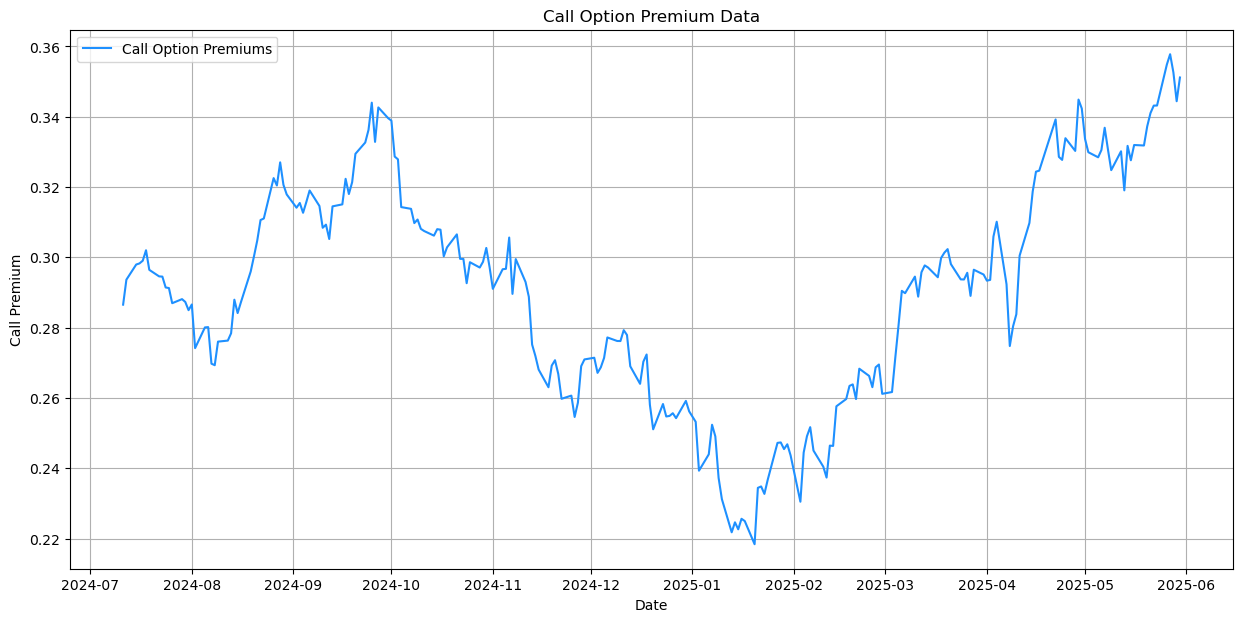

In [110]:
# Plot the call option premiums
plt.figure(figsize=(15, 7))
plt.grid(True)
plt.title("Call Option Premium Data")
plt.xlabel('Date')
plt.ylabel('Call Premium')
plt.plot(rt_1y.index, rt_1y['Call Premium'], label='Call Option Premiums', color = "dodgerblue")
plt.legend()
plt.show()

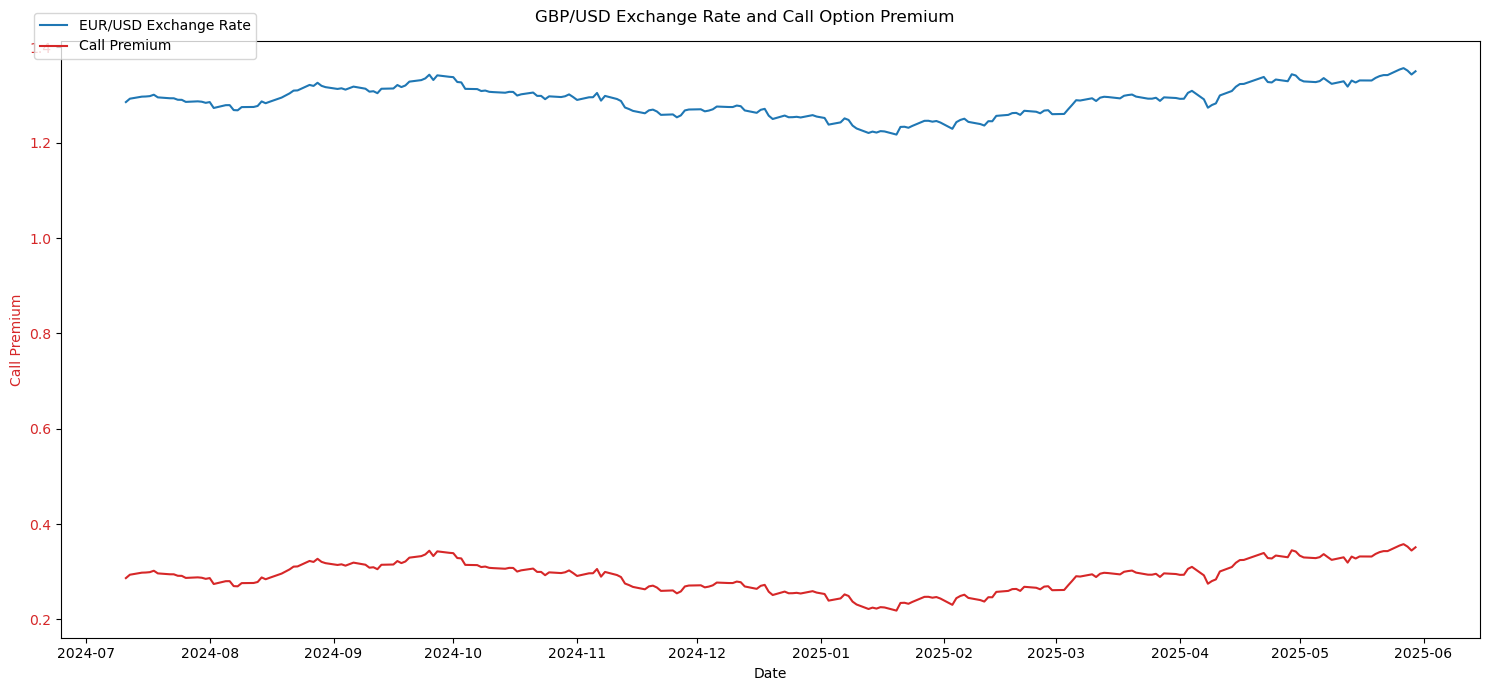

In [ ]:
fig, comparison = plt.subplots(figsize=(15, 7))

# EUR/USD exchange rate on the primary y-axis
comparison.set_xlabel('Date')
comparison.set_ylabel('GBP/USD Exchange Rate', color='tab:blue')
comparison.plot(rt_1y.index, rt_1y['Adj Close'], label='EUR/USD Exchange Rate', color='tab:blue')
comparison.tick_params(axis='y', labelcolor='tab:blue')

# The Call Premium on the secondary y-axis
comparison.set_ylabel('Call Premium', color='tab:red')
comparison.plot(rt_1y.index, rt_1y['Call Premium'], label='Call Premium', color='tab:red')
comparison.tick_params(axis='y', labelcolor='tab:red')

# title and legend
fig.suptitle('GBP/USD Exchange Rate and Call Option Premium')
fig.tight_layout()
fig.legend(loc='lower center', bbox_to_anchor=(0.1, 0.9))

# Show plot
plt.show()

### 2-YEAR

In [ ]:
rt_2y['Returns'] = rt_2y['Adj Close'].pct_change()
rt_2y = rt_2y.dropna()
print(rt_2y)

# Daily historical volatility (annualized)
rt_2y["volatility"] = rt_2y["Returns"].rolling(window = 30).std() * np.sqrt(252)
rt_2y = rt_2y.dropna().copy()

Price      Adj Close   Returns
Ticker      GBPUSD=X          
Date                          
2023-05-31  1.241188  0.005064
2023-06-01  1.244694  0.002825
2023-06-02  1.252599  0.006351
2023-06-05  1.243024 -0.007644
2023-06-06  1.243317  0.000236
...              ...       ...
2025-05-26  1.353583  0.008690
2025-05-27  1.356521  0.002170
2025-05-28  1.351333 -0.003824
2025-05-29  1.343147 -0.006058
2025-05-30  1.349899  0.005027

[520 rows x 2 columns]


In [ ]:
# Parameters for the option
K = 1  # strike price,
T = 30 / 365  # time to maturity: 30 days

# Call option premiums for each day
rt_2y['Call Premium'] = rt_2y.apply(
    lambda row: call_option_bsm(row['Adj Close'].item(), K, T, r, row['volatility'].item()), axis=1)

# Display the data with call premiums
print(rt_2y.tail())

Price      Adj Close   Returns volatility Call Premium
Ticker      GBPUSD=X                                  
Date                                                  
2025-05-26  1.353583  0.008690   0.090563     0.354864
2025-05-27  1.356521  0.002170   0.084161     0.357802
2025-05-28  1.351333 -0.003824   0.083702     0.352614
2025-05-29  1.343147 -0.006058   0.084354     0.344429
2025-05-30  1.349899  0.005027   0.084657     0.351181


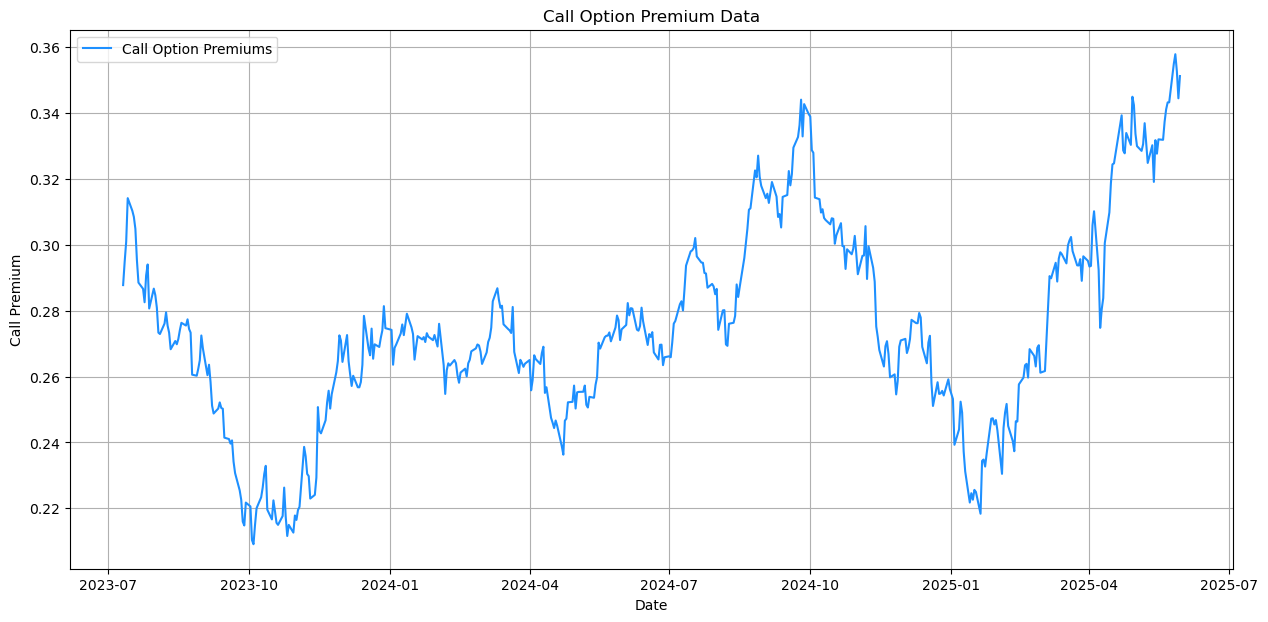

In [118]:
# Plot the call option premiums
plt.figure(figsize=(15, 7))
plt.grid(True)
plt.title("Call Option Premium Data")
plt.xlabel('Date')
plt.ylabel('Call Premium')
plt.plot(rt_2y.index, rt_2y['Call Premium'], label='Call Option Premiums', color = "dodgerblue")
plt.legend()
plt.show()

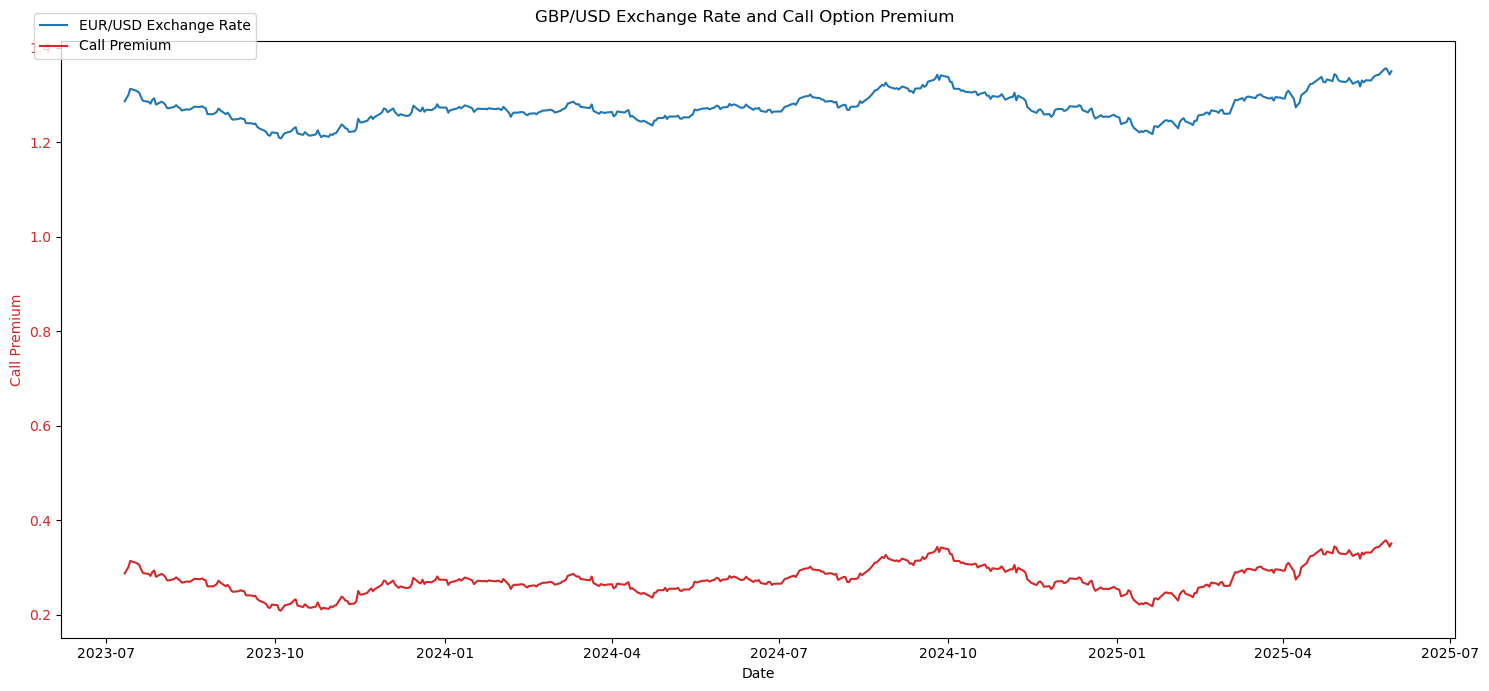

In [ ]:
fig, comparison = plt.subplots(figsize=(15, 7))

# EUR/USD exchange rate on the primary y-axis
comparison.set_xlabel('Date')
comparison.set_ylabel('GBP/USD Exchange Rate', color='tab:blue')
comparison.plot(rt_2y.index, rt_2y['Adj Close'], label='EUR/USD Exchange Rate', color='tab:blue')
comparison.tick_params(axis='y', labelcolor='tab:blue')

# The Call Premium on the secondary y-axis
comparison.set_ylabel('Call Premium', color='tab:red')
comparison.plot(rt_2y.index, rt_2y['Call Premium'], label='Call Premium', color='tab:red')
comparison.tick_params(axis='y', labelcolor='tab:red')

# title and legend
fig.suptitle('GBP/USD Exchange Rate and Call Option Premium')
fig.tight_layout()
fig.legend(loc='lower center', bbox_to_anchor=(0.1, 0.9))

# Show plot
plt.show()

### 5-YEAR

In [ ]:
rt_5y['Returns'] = rt_5y['Adj Close'].pct_change()
rt_5y = rt_5y.dropna()
print(rt_5y)

# Daily historical volatility (annualized)
rt_5y["volatility"] = rt_5y["Returns"].rolling(window = 30).std() * np.sqrt(252)
rt_5y = rt_5y.dropna().copy()

Price      Adj Close   Returns
Ticker      GBPUSD=X          
Date                          
2020-06-02  1.248704  0.011261
2020-06-03  1.258147  0.007562
2020-06-04  1.257514 -0.000503
2020-06-05  1.260907  0.002698
2020-06-08  1.272572  0.009252
...              ...       ...
2025-05-26  1.353583  0.008690
2025-05-27  1.356521  0.002170
2025-05-28  1.351333 -0.003824
2025-05-29  1.343147 -0.006058
2025-05-30  1.349899  0.005027

[1301 rows x 2 columns]


In [ ]:
# Parameters for the option
K = 1  # strike price,
T = 30 / 365  # time to maturity: 30 days

# Call option premiums for each day
rt_5y['Call Premium'] = rt_5y.apply(
    lambda row: call_option_bsm(row['Adj Close'].item(), K, T, r, row['volatility'].item()), axis=1)

# Display the data with call premiums
print(rt_5y.tail())

Price      Adj Close   Returns volatility Call Premium
Ticker      GBPUSD=X                                  
Date                                                  
2025-05-26  1.353583  0.008690   0.090563     0.354864
2025-05-27  1.356521  0.002170   0.084161     0.357802
2025-05-28  1.351333 -0.003824   0.083702     0.352614
2025-05-29  1.343147 -0.006058   0.084354     0.344429
2025-05-30  1.349899  0.005027   0.084657     0.351181


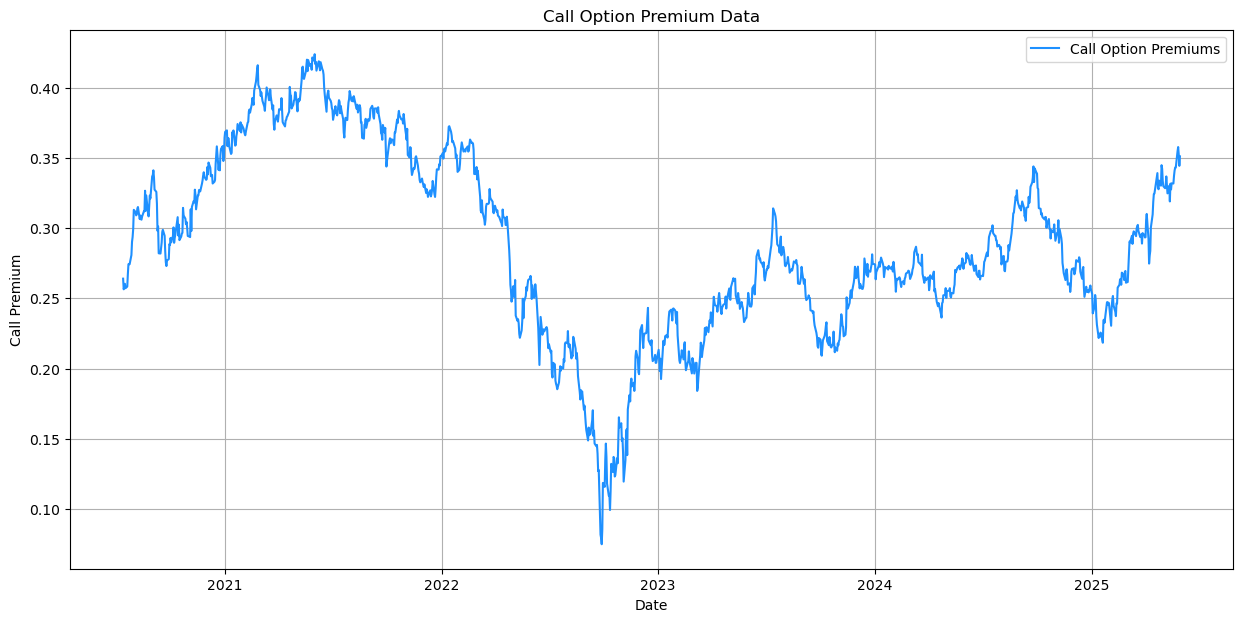

In [126]:
# Plot the call option premiums
plt.figure(figsize=(15, 7))
plt.grid(True)
plt.title("Call Option Premium Data")
plt.xlabel('Date')
plt.ylabel('Call Premium')
plt.plot(rt_5y.index, rt_5y['Call Premium'], label='Call Option Premiums', color = "dodgerblue")
plt.legend()
plt.show()

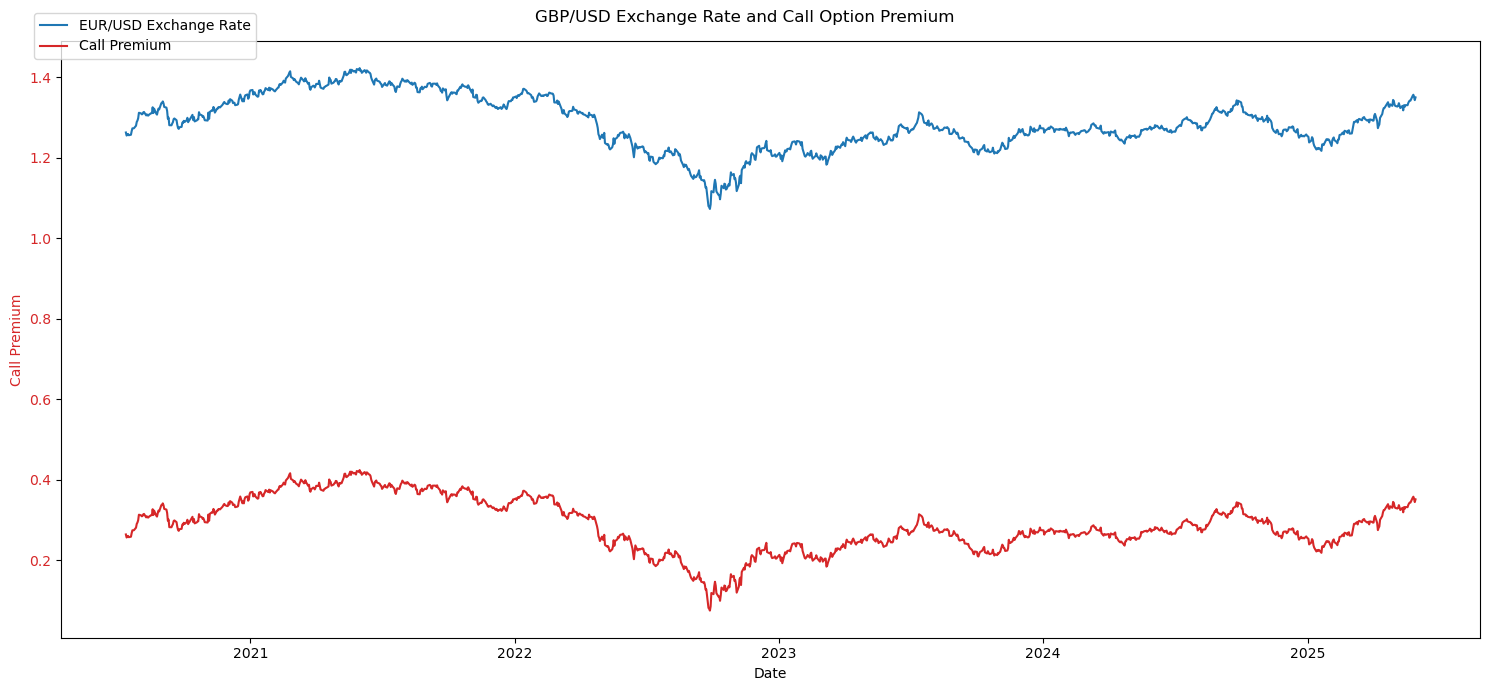

In [ ]:
fig, comparison = plt.subplots(figsize=(15, 7))

# EUR/USD exchange rate on the primary y-axis
comparison.set_xlabel('Date')
comparison.set_ylabel('GBP/USD Exchange Rate', color='tab:blue')
comparison.plot(rt_5y.index, rt_5y['Adj Close'], label='EUR/USD Exchange Rate', color='tab:blue')
comparison.tick_params(axis='y', labelcolor='tab:blue')

# The Call Premium on the secondary y-axis
comparison.set_ylabel('Call Premium', color='tab:red')
comparison.plot(rt_5y.index, rt_5y['Call Premium'], label='Call Premium', color='tab:red')
comparison.tick_params(axis='y', labelcolor='tab:red')

# title and legend
fig.suptitle('GBP/USD Exchange Rate and Call Option Premium')
fig.tight_layout()
fig.legend(loc='lower center', bbox_to_anchor=(0.1, 0.9))

# Show plot
plt.show()

## 10-YEAR

In [ ]:
rt_10y['Returns'] = rt_10y['Adj Close'].pct_change()
rt_10y = rt_10y.dropna()
print(rt_10y)

# Daily historical volatility (annualized)
rt_10y["volatility"] = rt_10y["Returns"].rolling(window = 30).std() * np.sqrt(252)
rt_10y = rt_10y.dropna().copy()

Price      Adj Close   Returns
Ticker      GBPUSD=X          
Date                          
2015-06-02  1.519988 -0.005821
2015-06-03  1.533978  0.009204
2015-06-04  1.532661 -0.000858
2015-06-05  1.536500  0.002504
2015-06-08  1.526788 -0.006321
...              ...       ...
2025-05-26  1.353583  0.008690
2025-05-27  1.356521  0.002170
2025-05-28  1.351333 -0.003824
2025-05-29  1.343147 -0.006058
2025-05-30  1.349899  0.005027

[2603 rows x 2 columns]


In [ ]:
# Parameters for the option
K = 1  # strike price,
T = 30 / 365  # time to maturity: 30 days

# Call option premiums for each day
rt_10y['Call Premium'] = rt_10y.apply(
    lambda row: call_option_bsm(row['Adj Close'].item(), K, T, r, row['volatility'].item()), axis=1)

# Display the data with call premiums
print(rt_10y.tail())

Price      Adj Close   Returns volatility Call Premium
Ticker      GBPUSD=X                                  
Date                                                  
2025-05-26  1.353583  0.008690   0.090563     0.354864
2025-05-27  1.356521  0.002170   0.084161     0.357802
2025-05-28  1.351333 -0.003824   0.083702     0.352614
2025-05-29  1.343147 -0.006058   0.084354     0.344429
2025-05-30  1.349899  0.005027   0.084657     0.351181


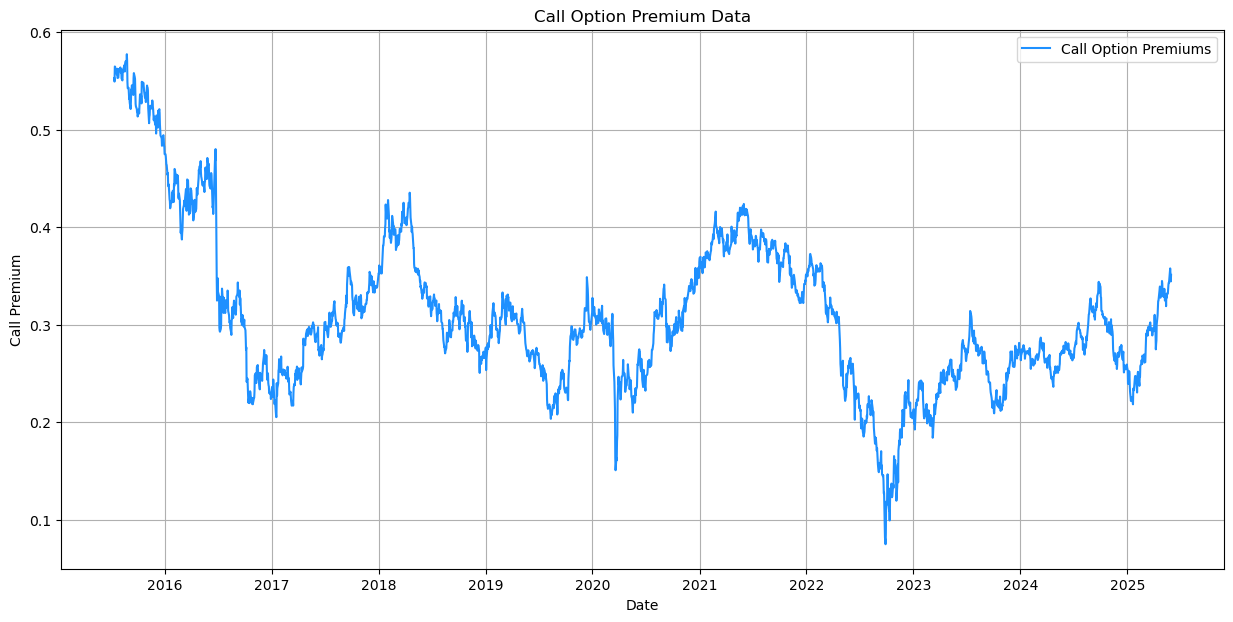

In [134]:
# Plot the call option premiums
plt.figure(figsize=(15, 7))
plt.grid(True)
plt.title("Call Option Premium Data")
plt.xlabel('Date')
plt.ylabel('Call Premium')
plt.plot(rt_10y.index, rt_10y['Call Premium'], label='Call Option Premiums', color = "dodgerblue")
plt.legend()
plt.show()

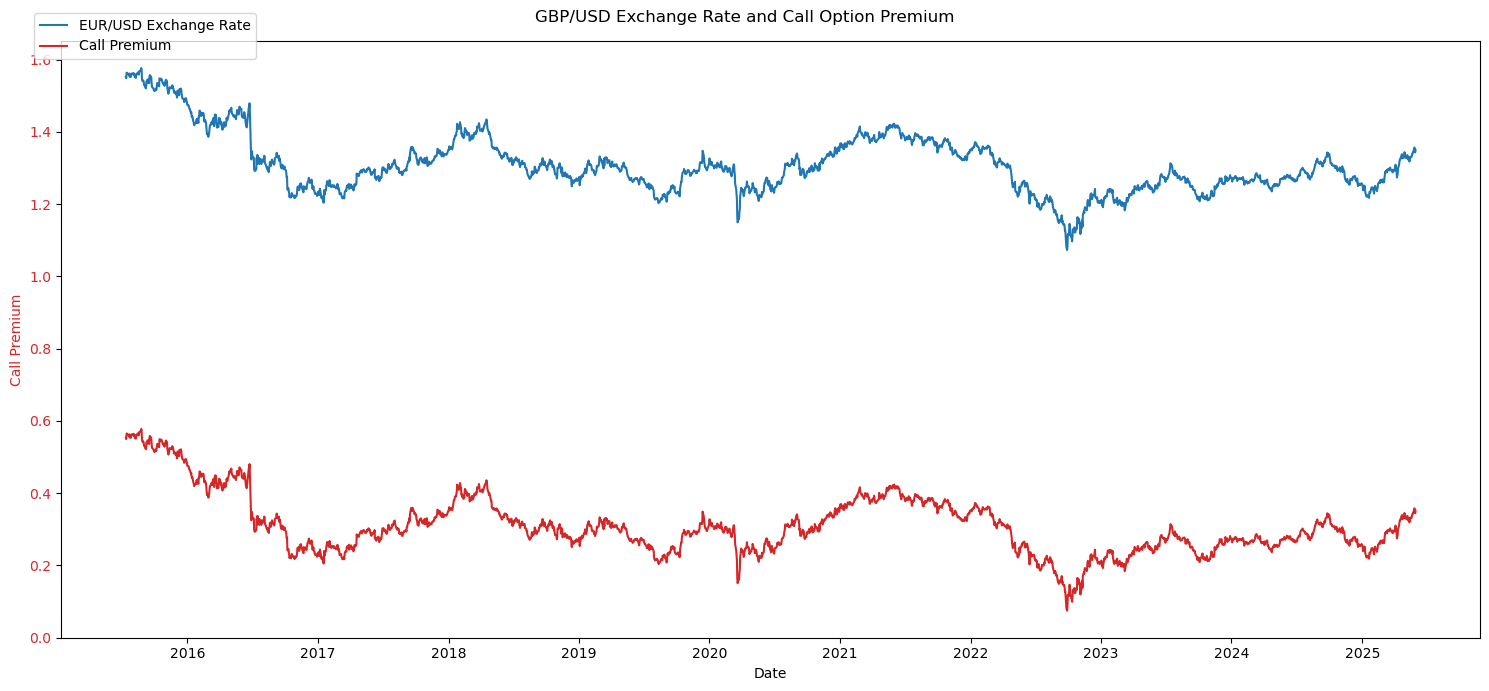

In [ ]:
fig, comparison = plt.subplots(figsize=(15, 7))

# EUR/USD exchange rate on the primary y-axis
comparison.set_xlabel('Date')
comparison.set_ylabel('GBP/USD Exchange Rate', color='tab:blue')
comparison.plot(rt_10y.index, rt_10y['Adj Close'], label='EUR/USD Exchange Rate', color='tab:blue')
comparison.tick_params(axis='y', labelcolor='tab:blue')

# The Call Premium on the secondary y-axis
comparison.set_ylabel('Call Premium', color='tab:red')
comparison.plot(rt_10y.index, rt_10y['Call Premium'], label='Call Premium', color='tab:red')
comparison.tick_params(axis='y', labelcolor='tab:red')

# title and legend
fig.suptitle('GBP/USD Exchange Rate and Call Option Premium')
fig.tight_layout()
fig.legend(loc='lower center', bbox_to_anchor=(0.1, 0.9))

# Show plot
plt.show()

### Showing the Payout of the Call

- By Defining a range and calculating the Pay-Out of the Currency Call Option, you can see that it matches the typical graphs, when we plot it.

In [ ]:
xS=np.linspace(0.25,2.25,100) #Define a range of exchange rate
def Call(St,E):
    P0=np.where(St>=E,St-E,0) #Calculate the Option Payout, depending on the Value of the Underlying
    return P0

- We chose the Strike Price at 1.25 and plot around that,

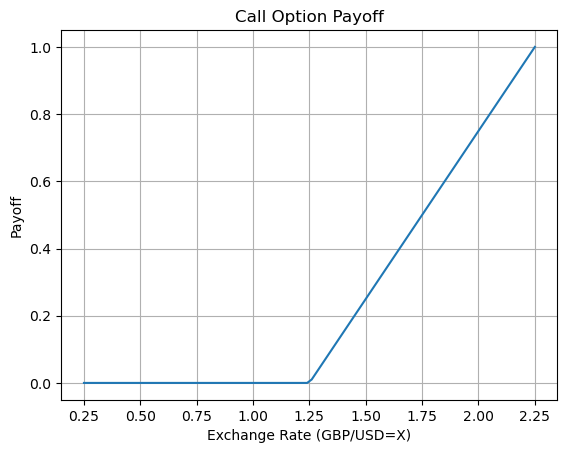

In [142]:
E = 1.25
plt.plot(xS,Call(xS,E))
plt.title('Call Option Payoff')
plt.xlabel('Exchange Rate (GBP/USD=X)')
plt.ylabel('Payoff')
plt.grid(True)
plt.show()

### Comparing with real option prices

- We have retrieved a Real Call Option Premium from Investing.com.
- We have decided to use the 12 month Call with T = 367 days, an Exercise Price of K = 1.2032 and an underlying implied volatility of 0.0974 as given on the website.
- The Real World Premium therefore is $C_R$ = 0.15377

In [147]:
# Parameters for the option
S = 1.3545
K = 1.2032  # strike price,
T = 367 / 365  # time to maturity:
r = 0.0156
sigma = 0.0974

# Calculate the Call option premium
C = call_option_bsm(S, K, T, r, sigma)
print(C)

0.17483022364707446


- Our calculated value with the BSM Model is $C_{\text{BSM}}$ = 0.17483

- This is quite a difference compared to the real world number.

- $C_{\text{BSM}} = 0.17483 > C_R = 0.15377$

- Our prediction is overshooting the true value, meaning that we would not be able to sell our product on the market, because other participants would value it as overpriced.
